In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:


"""
Model_tester.py
===============
Clean testing / evaluation script for Prism spectral emulators.

Tests included:
  1. Reduced chi-squared (χ²_red) — overall and binned by Teff, log g, [M/H], SNR
  2. Information leakage test — using apogee_mask.npy (full test set, all baselines)
  3. Reduced chi-squared by stellar type — cool giants, sun-like dwarfs, hot stars
"""

# ── Imports ──────────────────────────────────────────────────────────────
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras import layers, models, Input, regularizers
from sklearn.experimental import enable_iterative_imputer      # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from scipy.stats import binned_statistic, spearmanr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

# ── Configuration ────────────────────────────────────────────────────────
class Config:
    # --- Paths ---
    H5_PATH    = "/kaggle/input/datasets/aneeshshastri/aspcapstar-dr17-150kstars/apogee_dr17_parallel.h5"
    TFREC_DIR  = "/kaggle/working/tfrecords"
    STATS_PATH = "/kaggle/working/dataset_stats.npz"

    # --- Test-set range (stars beyond training + validation) ---
    # Training: 0 → 120,000   |   Validation: 120,000 → 140,000
    # Test:     140,000 → end of file
    TEST_START = 140_000

    # --- System ---
    RANDOM_SEED = 42

    # --- Model Hyperparameters ---
    BATCH_SIZE    = 64
    LEARNING_RATE = 1e-3
    EPOCHS        = 50
    LATENT_DIM    = 268
    OUTPUT_LENGTH = 8575

    # --- Loss related ---
    IVAR_SCALE   = 1000.0
    CLIP_NORM    = 1.0
    BADPIX_CUTOFF = 1e-3

    # --- Predictor labels ---
    # CAUTION: Order matters — everything follows this order.
    SELECTED_LABELS = [
        # 1. Core
        'TEFF', 'LOGG', 'M_H', 'VMICRO', 'VMACRO', 'VSINI',
        # 2. CNO
        'C_FE', 'N_FE', 'O_FE',
        # 3. Metals
        'FE_H',
        'MG_FE', 'SI_FE', 'CA_FE', 'TI_FE', 'S_FE',
        'AL_FE', 'MN_FE', 'NI_FE', 'CR_FE', 'K_FE',
        'NA_FE', 'V_FE', 'CO_FE',
    ]

    ABUNDANCE_INDICES = [i for i, label in enumerate(SELECTED_LABELS) if '_FE' in label]
    FE_H_INDEX = SELECTED_LABELS.index('FE_H')
    N_LABELS   = len(SELECTED_LABELS) + 4
    ERRORS     = [f'{label}_ERR' for label in SELECTED_LABELS]

    # --- Wavelength grid ---
    WAVELENGTH_START = 1514
    WAVELENGTH_END   = 1694

    # --- Label Groups for Masking ---
    CORE_LABELS = ['TEFF', 'LOGG', 'M_H', 'VMICRO', 'VMACRO', 'VSINI']
    CNO_LABELS  = ['C_FE', 'N_FE', 'O_FE']
    FEH_LABELS  = ['FE_H']
    TRACE_LABELS = ['MG_FE', 'SI_FE', 'CA_FE', 'TI_FE', 'S_FE',
                    'AL_FE', 'MN_FE', 'NI_FE', 'CR_FE', 'K_FE',
                     'NA_FE', 'V_FE', 'CO_FE',]


config = Config()
np.random.seed(config.RANDOM_SEED)
tf.random.set_seed(config.RANDOM_SEED)

# Global label indices for binning and masking
teff_idx = config.SELECTED_LABELS.index('TEFF')
logg_idx = config.SELECTED_LABELS.index('LOGG')
mh_idx   = config.SELECTED_LABELS.index('M_H')


# In[2]:


def get_nans(h5_path, selected_labels):
    """
    Scans the dataset and prints the percentage of unusable (NaN/Flagged) 
    data for each label.
    """
    print(f"Scanning {len(selected_labels)} labels for missing data...")
    print(f"{'LABEL':<10} | {'MISSING %':<10} | {'STATUS'}")
    
    missing_report = {}
    
    with h5py.File(h5_path, 'r') as f:
        # Detect structure (Group vs Table)
        if isinstance(f['metadata'], h5py.Group):
            get_col = lambda k: f['metadata'][k][:]
            keys = list(f['metadata'].keys())
        else:
            get_col = lambda k: f['metadata'][k]
            keys = f['metadata'].dtype.names

        # Get total count from the first label
        total_stars = len(get_col(selected_labels[0]))
        
        for label in selected_labels:
            # 1. Get Raw Values
            raw_vals = get_col(label)
            
            # 2. Check Flags (The Robust Logic)
            flag_name = f"{label}_FLAG"
            if flag_name in keys:
                flg = get_col(flag_name)
                # Handle Void/Structured types
                if flg.dtype.names: flg = flg[flg.dtype.names[0]]
                if flg.dtype.kind == 'V': flg = flg.view('<i4')
                
                # Bad if Flag != 0
                is_bad_flag = (flg.astype(int) != 0)
            else:
                is_bad_flag = np.zeros(total_stars, dtype=bool)
                
            # 3. Check Placeholder Values (Standard APOGEE -9999)
            # We check < -100 to catch any weird negative placeholders
            is_bad_val = (raw_vals < -100)
            
            # 4. Combine (Either Flagged OR Missing Value)
            total_bad = np.logical_or(is_bad_flag, is_bad_val)
            
            # 5. Calculate Stats
            bad_count = np.sum(total_bad)
            pct = (bad_count / total_stars) * 100
            missing_report[label] = pct
            
            # 6. Status Indicator
            if pct < 5.0:
                status = "Great"
            elif pct < 20.0:
                status = "Okay"
            else:
                status = "Hell Nah"
            
            print(f"{label:<10} | {pct:>9.2f}% | {status}")

    print("-" * 50)
    return missing_report
get_nans(config.H5_PATH,config.SELECTED_LABELS)

# ============================================================================
#  CUSTOM KERAS LAYERS (required for model loading)
# ============================================================================
@tf.keras.utils.register_keras_serializable()
class ChebyshevContinuum(layers.Layer):
    """
    Highly optimized Chebyshev pseudo-continuum generator.
    Evaluates C(lambda) = A * T(lambda) via single matrix multiplication.
    Mixed-precision safe.
    """
    def __init__(self, degree=15, n_pixels=8575, **kwargs):
        super().__init__(**kwargs)
        self.degree = degree
        self.n_pixels = n_pixels

    def build(self, input_shape):
        # 1. Generate normalized pixel grid [-1, 1]
        x = np.linspace(-1.0, 1.0, self.n_pixels, dtype=np.float32)
        
        # 2. Pre-compute Chebyshev polynomials T_n(x) via recurrence
        basis = np.zeros((self.degree, self.n_pixels), dtype=np.float32)
        if self.degree > 0:
            basis[0, :] = 1.0
        if self.degree > 1:
            basis[1, :] = x
        for i in range(2, self.degree):
            basis[i, :] = 2.0 * x * basis[i-1, :] - basis[i-2, :]
            
        # 3. Register as non-trainable weight for saving/loading
        self.basis = self.add_weight(
            name="chebyshev_basis",
            shape=(self.degree, self.n_pixels),
            initializer=tf.constant_initializer(basis),
            trainable=False,
            dtype=tf.float32 
        )
        super().build(input_shape)
    def call(self, coeffs):
        # Dynamically cast basis to match incoming coefficient dtype (e.g., float16)
        # Prevents crash under mixed_float16 policy.
        safe_basis = tf.cast(self.basis, coeffs.dtype)
        
        # O(O(N_batch * degree * n_pixels)) tensor multiplication
        return tf.matmul(coeffs, safe_basis)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.n_pixels)

    def get_config(self):
        config = super().get_config()
        config.update({
            'degree': self.degree, 
            'n_pixels': self.n_pixels
        })
        return config


@tf.keras.utils.register_keras_serializable()
class ColumnSelector(layers.Layer):
    """Selects specific columns from the input."""
    def __init__(self, indices, **kwargs):
        super().__init__(**kwargs)
        self.indices = list(indices)

    def call(self, inputs):
        return tf.gather(inputs, self.indices, axis=1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'indices': self.indices})
        return cfg


@tf.keras.utils.register_keras_serializable()
class BeerLambertLaw(layers.Layer):
    """Applies the Beer-Lambert law: Flux = k * exp(-Tau)."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, k, tau):
        return k * tf.math.exp(-tau)


@tf.keras.utils.register_keras_serializable()
class GetAbundances(layers.Layer):
    """Slices a single column from the input."""
    def __init__(self, col_id, **kwargs):
        super().__init__(**kwargs)
        self.index = col_id

    def call(self, inputs):
        return inputs[:, self.index : self.index + 1]
        
@tf.keras.utils.register_keras_serializable()
class SparseProjector(tf.keras.layers.Layer):
    def __init__(self, active_indices, weights, total_pixels, label_name="unknown", **kwargs):
        # Override name before passing to super to avoid conflict in from_config
        kwargs['name'] = f"Sparse_Projector_{label_name}"
        super().__init__(**kwargs)
        self.total_pixels = total_pixels
        self.label_name = label_name
        self.active_indices = tf.constant(active_indices, dtype=tf.int32)
        self.weights_tensor = tf.constant(weights, dtype=tf.float32)

    def call(self, local_tau):
        input_dtype = local_tau.dtype
        local_tau_32 = tf.cast(local_tau, tf.float32)
        weighted = local_tau_32 * self.weights_tensor[None, :]

        batch_size = tf.shape(local_tau)[0]
        n_active = tf.shape(self.active_indices)[0]

        batch_ids = tf.repeat(tf.range(batch_size), n_active)
        pixel_ids = tf.tile(self.active_indices, tf.expand_dims(batch_size, axis=0))

        scatter_idx = tf.stack([batch_ids, pixel_ids], axis=-1)
        flat_weighted = tf.reshape(weighted, [-1])

        full = tf.scatter_nd(
            scatter_idx,
            flat_weighted,
            shape=tf.stack([batch_size, tf.constant(self.total_pixels, dtype=tf.int32)])
        )
        # Cast back to original input dtype
        return tf.cast(full, input_dtype)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.total_pixels)

    def get_config(self):
        config = super().get_config()
        config.update({
            'active_indices': self.active_indices.numpy().tolist(),
            'weights': self.weights_tensor.numpy().tolist(),
            'total_pixels': self.total_pixels,
            'label_name': self.label_name,
        })
        return config

    @classmethod
    def from_config(cls, config):
        config['active_indices'] = np.array(config['active_indices'], dtype=np.int32)
        config['weights'] = np.array(config['weights'], dtype=np.float32)
        config.pop('name', None)  # remove saved name, __init__ constructs it from label_name
        return cls(**config)

# ============================================================================
#  CUSTOM LOSS / METRIC FUNCTIONS (required for model loading)
# ============================================================================

@register_keras_serializable()
def masked_spl_loss(y_true, y_pred):
    """
    Spectral pixel loss with per-star pixel masking.
    y_true: (batch, 8575, 3) -- ch0=flux, ch1=ivar, ch2=pixel_mask
    """
    if len(y_pred.shape) == 2:
        y_pred = tf.expand_dims(y_pred, -1)

    real_flux  = y_true[:, :, 0:1]
    ivar       = y_true[:, :, 1:2]
    pixel_mask = y_true[:, :, 2:3]

    valid_mask = tf.cast(real_flux > config.BADPIX_CUTOFF, tf.float32)
    safe_flux  = tf.where(valid_mask == 1.0, real_flux, y_pred)

    weight = 1e-5 / (1.0 / ivar + 1e-5)
    weight = tf.where(ivar > 0, weight, 0.0)

    wmse_term = tf.square(safe_flux - y_pred) * weight * valid_mask * pixel_mask
    return tf.where(tf.math.is_finite(wmse_term), wmse_term, tf.zeros_like(wmse_term))


@register_keras_serializable()
def masked_chi2_estimate(y_true, y_pred):
    """Chi-squared estimate compatible with 3-channel y_true."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    if len(y_pred.shape) == 2:
        y_pred = tf.expand_dims(y_pred, -1)

    real_flux  = y_true[:, :, 0:1]
    ivar       = y_true[:, :, 1:2]
    pixel_mask = y_true[:, :, 2:3]

    valid_mask = tf.cast(real_flux > config.BADPIX_CUTOFF, tf.float32)
    safe_flux  = tf.where(valid_mask == 1.0, real_flux, y_pred)

    weight = tf.where(ivar > 0, ivar, 0.0)
    wmse_term = tf.square(safe_flux - y_pred) * weight * valid_mask * pixel_mask

    n_valid = tf.reduce_sum(valid_mask * pixel_mask, 1)
    dof = n_valid - float(len(config.SELECTED_LABELS))
    return tf.reduce_sum(wmse_term, 1) / dof


@register_keras_serializable()
class GradientGate(layers.Layer):
    """
    Per-sample gradient severing for imputed label inputs.
    Forward: value is unchanged. Backward: gradient is zero for imputed labels.
    """
    def call(self, label_value, is_imputed):
        is_imputed = tf.cast(is_imputed, label_value.dtype)
        live = label_value * (1.0 - is_imputed)
        dead = tf.stop_gradient(label_value) * is_imputed
        return live + dead

    def get_config(self):
        return super().get_config()



@register_keras_serializable()
def chi2_estimate(y_true, y_pred):
    """Quick per-batch χ² estimate used as a Keras metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    if len(y_pred.shape) == 2:
        y_pred = tf.expand_dims(y_pred, -1)
    real_flux  = y_true[:, :, 0:1]
    ivar       = y_true[:, :, 1:2]
    valid_mask = tf.cast(real_flux > config.BADPIX_CUTOFF, tf.float32)
    safe_flux  = tf.where(valid_mask == 1.0, real_flux, y_pred)
    weight     = tf.where(ivar > 0, ivar, 0.0)
    wmse_term  = tf.square(safe_flux - y_pred) * weight * valid_mask
    n_valid    = tf.reduce_sum(valid_mask, 1)
    n_params   = len(config.SELECTED_LABELS)
    dof        = n_valid - n_params
    return tf.reduce_sum(wmse_term, 1) / dof


@register_keras_serializable()
def spl_loss(y_true, y_pred):
    """Spectral pixel loss — weighted MSE used during training."""
    if len(y_pred.shape) == 2:
        y_pred = tf.expand_dims(y_pred, -1)
    real_flux  = y_true[:, :, 0:1]
    ivar       = y_true[:, :, 1:2]
    valid_mask = tf.cast(real_flux > config.BADPIX_CUTOFF, tf.float32)
    safe_flux  = tf.where(valid_mask == 1.0, real_flux, y_pred)
    ivar_safe  = tf.clip_by_value(ivar / 1000.0, 0.0, 1.0)
    weight     = tf.where(
        (safe_flux < 0.9) & (ivar > 0),
        tf.maximum(ivar_safe, tf.cast(1.0, dtype=tf.float32)),
        ivar_safe,
    )
    wmse_term = tf.square(safe_flux - y_pred) * weight * valid_mask
    loss      = tf.where(tf.math.is_finite(wmse_term), wmse_term, tf.zeros_like(wmse_term))
    return loss


# ============================================================================
#  DATA LOADING HELPERS
# ============================================================================

def get_clean_imputed_data(h5_path, selected_labels, limit=None):
    """Read labels, flag bad values, impute, convert [X/Fe]→[X/H], engineer features."""
    print("Reading data for imputation …")
    with h5py.File(h5_path, 'r') as f:
        get_col = lambda k: f['metadata'][k]
        keys    = f['metadata'].dtype.names
        print(f"  Mean SNR (test slice): {np.mean(f['metadata']['SNR'][config.TEST_START:]):.1f}")

        raw_values = np.stack([get_col(p) for p in selected_labels], axis=1)
        bad_mask   = np.zeros_like(raw_values, dtype=bool)

        for i, label in enumerate(selected_labels):
            flag_name = f"{label}_FLAG"
            if flag_name in keys:
                flg = get_col(flag_name)
                if flg.dtype.names:
                    flg = flg[flg.dtype.names[0]]
                if flg.dtype.kind == 'V':
                    flg = flg.view('<i4')
                bad_mask[:, i] = flg.astype(int) != 0
            elif label in ['TEFF', 'LOGG', 'VMICRO', 'VMACRO', 'VSINI']:
                bad_mask[:, i] = raw_values[:, i] < -5000

    if limit:
        print(f"  Truncating to first {limit} stars.")
        raw_values = raw_values[:limit]
        bad_mask   = bad_mask[:limit]

    print(f"  Imputing labels for {len(raw_values)} stars …")
    vals = raw_values.copy()
    vals[bad_mask] = np.nan
    import joblib
    imputer = joblib.load("/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/23/imputer.pkl")
    clean   = imputer.transform(vals)

    # [X/Fe] → [X/H]
    print("  Converting [X/Fe] → [X/H] …")
    fe_h = clean[:, config.FE_H_INDEX : config.FE_H_INDEX + 1]
    for idx in config.ABUNDANCE_INDICES:
        clean[:, idx] += fe_h[:, 0]

    # Engineer features
    teff_idx  = selected_labels.index('TEFF')
    inv_teff  = (5040.0 / (clean[:, teff_idx] + 1e-6)).reshape(-1, 1)
    clean     = np.hstack([clean, inv_teff])

    vmacro_vals = clean[:, selected_labels.index('VMACRO')]
    vsini_vals  = clean[:, selected_labels.index('VSINI')]
    vbroad      = np.sqrt(vmacro_vals**2 + vsini_vals**2).reshape(-1, 1)
    clean       = np.hstack([clean, vbroad])

    c_vals = clean[:, selected_labels.index('C_FE')]
    o_vals = clean[:, selected_labels.index('O_FE')]
    clean  = np.hstack([clean, (c_vals - o_vals).reshape(-1, 1)])

    g_vals = clean[:, selected_labels.index('LOGG')]
    m_vals = clean[:, selected_labels.index('M_H')]
    clean  = np.hstack([clean, (0.5 * g_vals + 0.5 * m_vals).reshape(-1, 1)])

    print(f"  Final label shape: {clean.shape}")
    return clean, bad_mask


def get_err(h5_path, selected_labels,labels=config.SELECTED_LABELS,limit=None):
    """Read label uncertainties, fill missing with 95th-percentile fallback."""
    print("Reading label errors …")
    with h5py.File(h5_path, 'r') as f:
        get_col = lambda k: f['metadata'][k]
        keys    = f['metadata'].dtype.names
        raw = np.stack([
            get_col(p) if p not in ['VMACRO_ERR', 'VMICRO_ERR', 'VSINI_ERR']
            else np.zeros_like(get_col('TEFF_ERR'))
            for p in selected_labels
        ], axis=1)

        bad_mask = np.zeros_like(raw, dtype=bool)
        for i, label in enumerate(selected_labels):
            flag_name = f"{labels[i]}_FLAG"
            if flag_name in keys:
                flg = get_col(flag_name)
                if flg.dtype.names:
                    flg = flg[flg.dtype.names[0]]
                if flg.dtype.kind == 'V':
                    flg = flg.view('<i4')
                bad_mask[:, i] = flg.astype(int) != 0
            elif label in ['TEFF', 'LOGG', 'VMICRO', 'VMACRO', 'VSINI']:
                bad_mask[:, i] = raw[:, i] < -5000

    if limit:
        raw      = raw[:limit]
        bad_mask = bad_mask[:limit]

    vals = raw.copy()
    vals[bad_mask] = np.nan
    fallback = np.nanpercentile(vals, 95, axis=0)
    return np.where(np.isnan(vals), fallback, vals)

2026-05-02 19:25:00.457420: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777749900.651744      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777749900.702753      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777749901.182342      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777749901.182420      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777749901.182427      23 computation_placer.cc:177] computation placer alr

Scanning 23 labels for missing data...
LABEL      | MISSING %  | STATUS
TEFF       |      0.00% | Great
LOGG       |      0.00% | Great
M_H        |      0.00% | Great
VMICRO     |      0.00% | Great
VMACRO     |      0.00% | Great
VSINI      |      0.00% | Great
C_FE       |      0.55% | Great
N_FE       |     10.34% | Okay
O_FE       |      0.50% | Great
FE_H       |      0.47% | Great
MG_FE      |      0.47% | Great
SI_FE      |      0.46% | Great
CA_FE      |      1.01% | Great
TI_FE      |     10.14% | Okay
S_FE       |      5.17% | Okay
AL_FE      |      4.91% | Great
MN_FE      |      8.29% | Okay
NI_FE      |      2.05% | Great
CR_FE      |      5.18% | Okay
K_FE       |      3.24% | Great
NA_FE      |      4.33% | Great
V_FE       |      2.51% | Great
CO_FE      |     13.81% | Okay
--------------------------------------------------


In [2]:
# ============================================================================
#  MODEL PATHS 
# ============================================================================
n_pixels = 8575
h5_path  = "/kaggle/input/datasets/aneeshshastri/aspcapstar-dr17-150kstars/apogee_dr17_parallel.h5"

stats_path = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/23/dataset_stats_120k.npz"

# Main Prism model
model_path = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/23/APOGEE_SGEN.keras"

# Baseline models — TODO:
model_path_P  = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/23/ThePayne.keras"
model_path_EP = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/23/Expanded_Payne.keras" 
model_path_AbPrism = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/23/SPECTROGRAM_GENERATOR.keras"       
model_path_RP = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/23/RegPayne.keras"        

# Mask for leakage test — uses apogee_mask.npy (NOT jacobian_mask.npy)
apogee_mask_path = "/kaggle/input/datasets/aneeshshastri/element-masks/apogee_mask.npy"    


# ============================================================================
#  LOAD DATA — Full Test Set
# ============================================================================
print("Loading test data …")
f = h5py.File(h5_path, 'r')
n_total_stars = f['flux'].shape[0]
test_end = n_total_stars  # use ALL stars from TEST_START to end

real_data      = f['flux'][config.TEST_START:test_end]
real_data_ivar = f['ivar'][config.TEST_START:test_end]

with np.load(stats_path) as data:
    MEAN_TENSOR = data['mean'].astype(np.float32)
    STD_TENSOR  = data['std'].astype(np.float32)

labels, bad_mask_full = get_clean_imputed_data(h5_path, config.SELECTED_LABELS)
label_err = get_err(h5_path, config.ERRORS)

labels = (labels - MEAN_TENSOR) / STD_TENSOR

# Slice for test set
test_labels    = labels[config.TEST_START:test_end]
test_label_err = label_err[config.TEST_START:test_end]
test_bad_mask  = bad_mask_full[config.TEST_START:test_end]
n_test = len(test_labels)
print(f"Test set: {n_test} stars (indices {config.TEST_START} → {test_end})")

# Read metadata for grouping
with h5py.File(h5_path, 'r') as hf:
    SNR = hf['metadata']['SNR'][config.TEST_START:test_end]


# In[4]:

Loading test data …
Reading data for imputation …
  Mean SNR (test slice): 274.0
  Imputing labels for 149966 stars …
  Converting [X/Fe] → [X/H] …
  Final label shape: (149966, 27)
Reading label errors …
Test set: 9966 stars (indices 140000 → 149966)


In [3]:
# ============================================================================
#  LOAD MODELS & GENERATE PREDICTIONS
# ============================================================================
print("\nLoading models and generating predictions …")

model = tf.keras.models.load_model(model_path)
gen_data = model.predict(
    [test_labels, np.zeros((len(test_labels), 23), dtype=np.float32)],
    batch_size=256
)

ThePayne = tf.keras.models.load_model(model_path_P)
gen_data_P = tf.cast(ThePayne.predict(test_labels), tf.float32)

ExpandedPayne = tf.keras.models.load_model(model_path_EP)
gen_data_EP = tf.cast(ExpandedPayne.predict(test_labels), tf.float32)

base_AbPrism = tf.keras.models.load_model(model_path_AbPrism)
gen_data_AbPrism = tf.cast(base_AbPrism.predict(test_labels), tf.float32)

reg_Payne = tf.keras.models.load_model(model_path_RP)
gen_data_RP = tf.cast(reg_Payne.predict(test_labels), tf.float32)


# In[5]:


Loading models and generating predictions …


I0000 00:00:1777749994.553030      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1777750001.507238      65 service.cc:152] XLA service 0x7f31e0002010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777750001.507282      65 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777750001.996328      65 cuda_dnn.cc:529] Loaded cuDNN version 91002


15/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

I0000 00:00:1777750004.098101      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 25 variables whereas the saved optimizer has 21 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 21 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [4]:
import tensorflow as tf
import numpy as np

# ============================================================================
#  UTILITY: Forward-Mode Analytical Gradient
# ============================================================================
def get_gradient(model_obj, base_labels, idx, epsilon=None,isprism=False):
    """Exact gradient via forward-mode autodiff. Epsilon is ignored."""
    base_labels = tf.cast(base_labels, tf.float32)
    n_labels = base_labels.shape[1]
    
    # Define tangent vector: 1.0 for the parameter we want to differentiate, 0.0 for the rest
    tangent = tf.one_hot(indices=idx, depth=n_labels, dtype=tf.float32)
    tangent_batch = tf.broadcast_to(tangent, tf.shape(base_labels))
    
    with tf.autodiff.ForwardAccumulator(base_labels, tangent_batch) as acc:
        if isprism:
             flux_base =tf.cast(model_obj(
                [base_labels, tf.zeros((len(base_labels), 23), dtype=tf.float32)],
                batch_size=256),tf.float32)
        else:

            flux_base = tf.cast(model_obj(base_labels, training=False), tf.float32)
        
    dF_dl = acc.jvp(flux_base)
    
    if dF_dl is None:
        dF_dl = tf.zeros_like(flux_base)
    elif len(dF_dl.shape) == 3:
        dF_dl = dF_dl[:, :, 0]
        
    return tf.cast(dF_dl / STD_TENSOR[idx], tf.float32)

# ============================================================================
#  TEST 1: REDUCED CHI-SQUARED (Forward-Mode AD)
# ============================================================================
def reduced_chi_square(y_true, y_pred, ivar, lab, lab_err,
                       batch_size=512,
                       selected_labels=config.SELECTED_LABELS,
                       model_obj=None,
                       n_pix=config.OUTPUT_LENGTH,
                       VAR_FLOOR=1e-5):
    """
    Compute reduced χ² per star with exact analytical error propagation 
    using memory-efficient Forward-Mode AD.
    """
    y_pred = tf.where(y_true < config.BADPIX_CUTOFF, y_true, y_pred)
    n_samples = len(y_true)
    n_batches = n_samples // batch_size
    reduced_chi2 = np.zeros(n_batches * batch_size)

    print(f"  Computing χ² for {n_batches} batches via forward-mode autodiff ...")
    for k in range(n_batches):
        s, e = k * batch_size, (k + 1) * batch_size
        label_b = tf.identity(tf.cast(lab[s:e], tf.float32))
        label_err_b = tf.cast(lab_err[s:e], tf.float32)
        y_true_b    = y_true[s:e]
        y_pred_b    = y_pred[s:e]
        ivar_b      = ivar[s:e]
        n_lab       = label_b.shape[1]
        '''
        sigma_model_sq = tf.zeros((batch_size, n_pix), dtype=tf.float32)
        
        # Iterate over the 23 input labels instead of 8575 output pixels
        for j in range(len(selected_labels)):
            tangent = tf.one_hot(indices=j, depth=n_lab, dtype=tf.float32)
            tangent_batch = tf.broadcast_to(tangent, tf.shape(label_b))

            with tf.autodiff.ForwardAccumulator(label_b, tangent_batch) as acc:
                flux_base = tf.cast(model_obj(label_b, training=False), tf.float32)

            grad = acc.jvp(flux_base)

            # Handle structurally disconnected parameters (e.g., zero-weight masks)
            if grad is None:
                grad = tf.zeros_like(flux_base)
            elif len(grad.shape) == 3:
                grad = grad[:, :, 0]

            grad_scaled = grad / tf.cast(STD_TENSOR[j], tf.float32)
            err_expanded = tf.expand_dims(label_err_b[:, j], axis=1)
            
            sigma_model_sq += (grad_scaled * err_expanded)**2
            '''
        valid_mask = ((ivar_b > 0) & (y_true_b > config.BADPIX_CUTOFF)).astype(np.float32)
        safe_ivar  = np.maximum(ivar_b, 0)
        
        with np.errstate(divide='ignore'):
            var_instr = np.where(safe_ivar > 0, 1.0 / safe_ivar, 0.0)
          
        var_total  = var_instr + VAR_FLOOR
        chi_pix    = (y_pred_b - y_true_b)**2 / var_total * valid_mask
        chi_sum    = np.sum(chi_pix, axis=1)
        n_valid    = np.sum(valid_mask, axis=1)
        dof        = np.maximum(n_valid - len(selected_labels), 1)
        
        reduced_chi2[s:e] = chi_sum / dof

        if k % 5 == 0:
            print(f"    Batch {k}/{n_batches}")

    return reduced_chi2


# In[6]:


print("\n" + "=" * 60)
print("  TEST 1 — REDUCED CHI-SQUARED")
print("=" * 60)

test_chi2 = reduced_chi_square(
    real_data, gen_data, real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=model,
)

test_chi2_P = reduced_chi_square(
    real_data, gen_data_P, real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=ThePayne,
)

test_chi2_EP = reduced_chi_square(
    real_data, gen_data_EP[:, :, 0] if len(gen_data_EP.shape) > 2 else gen_data_EP,
    real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=ExpandedPayne,
)

test_chi2_AbPrism = reduced_chi_square(
    real_data, gen_data_AbPrism[:, :, 0] if len(gen_data_AbPrism.shape) > 2 else gen_data_AbPrism,
    real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=base_AbPrism,
)

test_chi2_RP = reduced_chi_square(
    real_data, gen_data_RP, real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=reg_Payne,
)


  TEST 1 — REDUCED CHI-SQUARED
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19


In [5]:
# ============================================================================
#  TEST 4: IMPUTED VS NON-IMPUTED LABELS
# ============================================================================
def test_imputed_vs_non_imputed(chi2_array, bad_mask, labels=config.SELECTED_LABELS):
    """Compare mean chi-squared for stars with imputed vs non-imputed labels."""
    print("\n" + "=" * 60)
    print("  TEST 4 — IMPUTED VS NON-IMPUTED LABELS")
    print("=" * 60)
    print(f"{'Label':<10} | {'Imputed Count':<15} | {'Chi2 Imputed':<15} | {'Chi2 Natural':<15} | {'Ratio'}")
    print("-" * 75)

    for i, label in enumerate(labels):
        imputed_idx = bad_mask[:, i][:len(chi2_array)]
        natural_idx = ~imputed_idx

        if np.any(imputed_idx) and np.any(natural_idx):
            chi2_imp = np.mean(chi2_array[imputed_idx])
            chi2_nat = np.mean(chi2_array[natural_idx])
            ratio = chi2_imp / chi2_nat
            print(f"{label:<10} | {np.sum(imputed_idx):<15} | {chi2_imp:>12.3f} | {chi2_nat:>12.3f} | {ratio:>8.2f}")

# Run Test 4 for Prism
test_imputed_vs_non_imputed(test_chi2, test_bad_mask)


  TEST 4 — IMPUTED VS NON-IMPUTED LABELS
Label      | Imputed Count   | Chi2 Imputed    | Chi2 Natural    | Ratio
---------------------------------------------------------------------------
C_FE       | 53              |       33.176 |        2.006 |    16.54
N_FE       | 992             |        4.124 |        1.954 |     2.11
O_FE       | 46              |       37.367 |        2.009 |    18.60
FE_H       | 44              |       38.948 |        2.009 |    19.39
MG_FE      | 43              |       39.795 |        2.009 |    19.81
SI_FE      | 43              |       39.795 |        2.009 |    19.81
CA_FE      | 94              |       22.454 |        1.978 |    11.35
TI_FE      | 927             |        5.026 |        1.876 |     2.68
S_FE       | 463             |        7.381 |        1.916 |     3.85
AL_FE      | 442             |        7.568 |        1.919 |     3.94
MN_FE      | 756             |        5.563 |        1.890 |     2.94
NI_FE      | 203             |       12


  RECALCULATING MASKED CHI-SQUARED

  Masking Logic:
    Total stars: 9966
    Dropped stars: 1028
    Retained stars: 8938
    Batch 0/17 (Masked)
    Batch 10/17 (Masked)

Retained Stars Distributions:
  TEFF: Mean=4575.5, Std=396.6, Range=[3203.0, 6048.4]
  LOGG: Mean=2.20, Std=0.69, Range=[0.00, 4.58]
  M_H:  Mean=-0.232, Std=0.328, Range=[-2.247, 0.538]

  Masking Logic:
    Total stars: 9966
    Dropped stars: 1028
    Retained stars: 8938
    Batch 0/17 (Masked)
    Batch 10/17 (Masked)

  Masking Logic:
    Total stars: 9966
    Dropped stars: 1028
    Retained stars: 8938
    Batch 0/17 (Masked)
    Batch 10/17 (Masked)

  Masking Logic:
    Total stars: 9966
    Dropped stars: 1028
    Retained stars: 8938
    Batch 0/17 (Masked)
    Batch 10/17 (Masked)

  Masking Logic:
    Total stars: 9966
    Dropped stars: 1028
    Retained stars: 8938
    Batch 0/17 (Masked)
    Batch 10/17 (Masked)

  SUMMARY: MASKED CHI-SQUARED RESULTS

Prism:
  Mean   = 1.941
  Median = 1.718
  95t

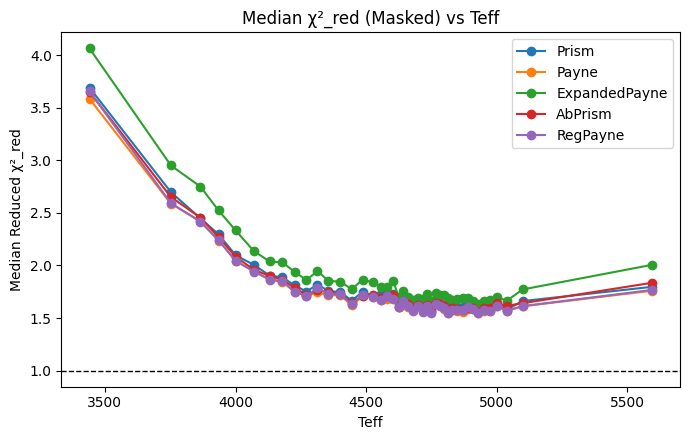

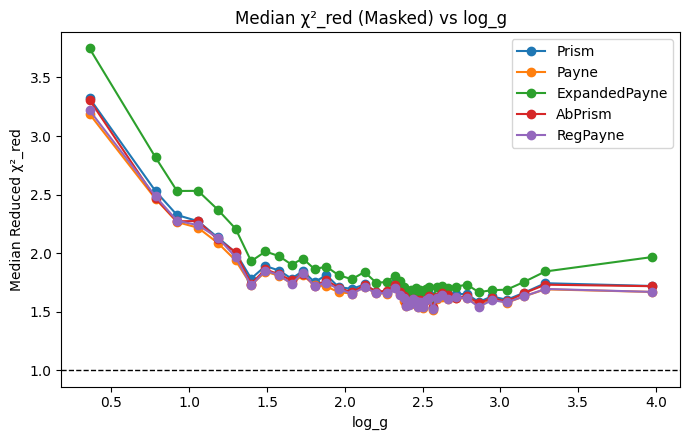

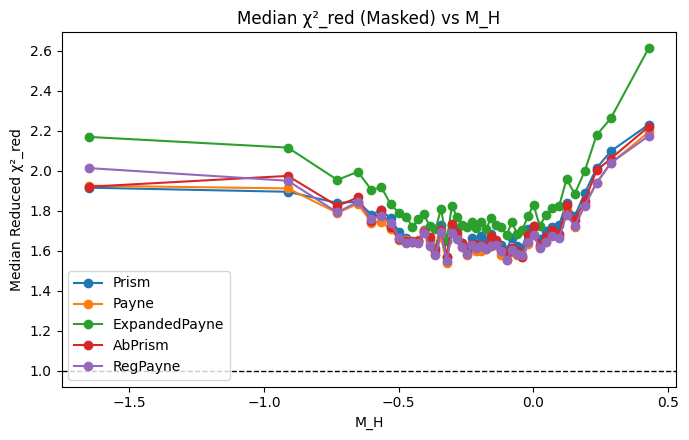

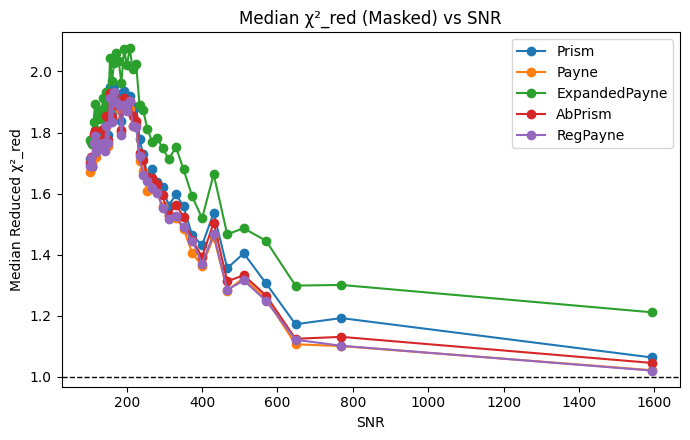

In [6]:
# ============================================================================
#  RECALCULATE CHI-SQUARED WITH MASKING LOGIC
# ============================================================================
def reduced_chi_square_masked(y_true, y_pred, ivar, lab, lab_err, bad_mask,
                              apogee_mask_data,
                              batch_size=512,
                              selected_labels=config.SELECTED_LABELS,
                              model_obj=None,
                              n_pix=config.OUTPUT_LENGTH,
                              VAR_FLOOR=1e-5):
    """
    Recalculate Chi-squared with masking:
    1. Drop stars with imputed CORE, CNO, or FEH labels.
    2. For trace elements, mask pixels with weight > 0.01 in apogee_mask if imputed.
    """
    # 1. Identify valid stars (not dropped by core/cno/feh imputation)
    core_cno_feh_indices = [selected_labels.index(l) for l in config.CORE_LABELS + config.CNO_LABELS + config.FEH_LABELS]
    dropped_mask = np.any(bad_mask[:, core_cno_feh_indices], axis=1)
    valid_stars_mask = ~dropped_mask

    print(f"\n  Masking Logic:")
    print(f"    Total stars: {len(valid_stars_mask)}")
    print(f"    Dropped stars: {np.sum(dropped_mask)}")
    print(f"    Retained stars: {np.sum(valid_stars_mask)}")

    # Slice data to valid stars
    y_true_v  = y_true[valid_stars_mask]
    y_pred_v  = y_pred[valid_stars_mask]
    ivar_v    = ivar[valid_stars_mask]
    lab_v     = lab[valid_stars_mask]
    lab_err_v = lab_err[valid_stars_mask]
    bad_mask_v = bad_mask[valid_stars_mask]

    n_samples = len(y_true_v)
    n_batches = n_samples // batch_size
    reduced_chi2 = np.zeros(n_batches * batch_size)

    # Pre-calculate masks for trace elements
    trace_indices = [selected_labels.index(l) for l in config.TRACE_LABELS if l in config.SELECTED_LABELS]
    # apogee_mask labels order: config.SELECTED_LABELS + ...
    trace_masks = {idx: (apogee_mask_data[:, idx] > 0.01) for idx in trace_indices}

    for k in range(n_batches):
        s, e = k * batch_size, (k + 1) * batch_size
        y_true_b   = y_true_v[s:e]
        y_pred_b   = y_pred_v[s:e]
        ivar_b     = ivar_v[s:e]
        bad_mask_b = bad_mask_v[s:e]

        # Initial valid mask (instrumental)
        valid_mask = ((ivar_b > 0) & (y_true_b > config.BADPIX_CUTOFF)).astype(np.float32)

        # Apply pixel-wise masking for imputed trace elements
        for idx in trace_indices:
            # For each star in batch, if label idx was imputed, apply its pixel mask
            imputed_stars_in_batch = bad_mask_b[:, idx]
            if np.any(imputed_stars_in_batch):
                # Apply mask to those stars: mask is True where we should EXCLUDE
                pixel_mask = trace_masks[idx]
                # valid_mask[imputed_stars_in_batch, pixel_mask] = 0.0
                # Using numpy broadcasting
                valid_mask[imputed_stars_in_batch, :] *= (~pixel_mask).astype(np.float32)

        safe_ivar = np.maximum(ivar_b, 0)
        with np.errstate(divide='ignore'):
            var_instr = np.where(safe_ivar > 0, 1.0 / safe_ivar, 0.0)

        var_total = var_instr + VAR_FLOOR
        chi_pix   = (y_pred_b - y_true_b)**2 / var_total * valid_mask
        chi_sum   = np.sum(chi_pix, axis=1)
        n_valid   = np.sum(valid_mask, axis=1)
        dof       = np.maximum(n_valid - len(selected_labels), 1)

        reduced_chi2[s:e] = chi_sum / dof

        if k % 10 == 0:
             print(f"    Batch {k}/{n_batches} (Masked)")

    return reduced_chi2, valid_stars_mask

# Load apogee_mask for masking logic
apogee_mask = np.load(apogee_mask_path)

print("\n" + "=" * 60)
print("  RECALCULATING MASKED CHI-SQUARED")
print("=" * 60)

test_chi2_masked, valid_stars = reduced_chi_square_masked(
    real_data, gen_data, real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    test_bad_mask, apogee_mask,
    model_obj=model
)

# Report distributions of valid stars
teff_v = test_labels[valid_stars, teff_idx] * STD_TENSOR[teff_idx] + MEAN_TENSOR[teff_idx]
logg_v = test_labels[valid_stars, logg_idx] * STD_TENSOR[logg_idx] + MEAN_TENSOR[logg_idx]
mh_v   = test_labels[valid_stars, mh_idx]   * STD_TENSOR[mh_idx]   + MEAN_TENSOR[mh_idx]

print("\nRetained Stars Distributions:")
print(f"  TEFF: Mean={np.mean(teff_v):.1f}, Std={np.std(teff_v):.1f}, Range=[{np.min(teff_v):.1f}, {np.max(teff_v):.1f}]")
print(f"  LOGG: Mean={np.mean(logg_v):.2f}, Std={np.std(logg_v):.2f}, Range=[{np.min(logg_v):.2f}, {np.max(logg_v):.2f}]")
print(f"  M_H:  Mean={np.mean(mh_v):.3f}, Std={np.std(mh_v):.3f}, Range=[{np.min(mh_v):.3f}, {np.max(mh_v):.3f}]")

# Run for other models as well (to keep comparisons consistent)
test_chi2_P_masked, _ = reduced_chi_square_masked(
    real_data, gen_data_P, real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    test_bad_mask, apogee_mask, model_obj=ThePayne
)
test_chi2_EP_masked, _ = reduced_chi_square_masked(
    real_data, gen_data_EP[:, :, 0] if len(gen_data_EP.shape) > 2 else gen_data_EP,
    real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    test_bad_mask, apogee_mask, model_obj=ExpandedPayne
)
test_chi2_AbPrism_masked, _ = reduced_chi_square_masked(
    real_data, gen_data_AbPrism[:, :, 0] if len(gen_data_AbPrism.shape) > 2 else gen_data_AbPrism,
    real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    test_bad_mask, apogee_mask, model_obj=base_AbPrism
)
test_chi2_RP_masked, _ = reduced_chi_square_masked(
    real_data, gen_data_RP, real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    test_bad_mask, apogee_mask, model_obj=reg_Payne
)

# ── Print summary ──
print("\n" + "=" * 60)
print("  SUMMARY: MASKED CHI-SQUARED RESULTS")
print("=" * 60)
for name, chi2 in [("Prism", test_chi2_masked), ("Payne", test_chi2_P_masked),
                    ("ExpandedPayne", test_chi2_EP_masked), ("AbPrism", test_chi2_AbPrism_masked),
                    ("RegPayne", test_chi2_RP_masked)]:
    print(f"\n{name}:")
    print(f"  Mean   = {chi2.mean():.3f}")
    print(f"  Median = {np.median(chi2):.3f}")
    print(f"  95th % = {np.percentile(chi2, 95):.3f}")


# ── Binned plots ──
def quantile_bins(x, min_per_bin=200):
    n_bins = max(5, len(x) // min_per_bin)
    return np.quantile(x, np.linspace(0, 1, n_bins + 1))


def plot_binned_stat(x, chi2_dict, bins, xlabel, stat='median'):
    """Plot binned statistic for multiple models. chi2_dict = {name: array}."""
    plt.figure(figsize=(7, 4.5))
    for name, y in chi2_dict.items():
        # Ensure x and y have the same length (y is from masked stars)
        vals, edges, _ = binned_statistic(x[:len(y)], y, statistic=stat, bins=bins)
        count, _, _    = binned_statistic(x[:len(y)], y, statistic='count', bins=bins)
        centres = 0.5 * (edges[:-1] + edges[1:])
        mask    = count > 10
        plt.plot(centres[mask], vals[mask], 'o-', label=name)
    plt.axhline(1.0, ls='--', color='black', lw=1)
    plt.xlabel(xlabel)
    plt.ylabel(f"{stat.capitalize()} Reduced χ²_red")
    plt.title(f"{stat.capitalize()} χ²_red (Masked) vs {xlabel}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{stat}_chi2_vs_{xlabel}_masked.png")
    plt.show()


# Align chi2 arrays with valid stars
n_masked = len(test_chi2_masked)
teff_phys = (test_labels[valid_stars, teff_idx] * STD_TENSOR[teff_idx] + MEAN_TENSOR[teff_idx])[:n_masked]
logg_phys = (test_labels[valid_stars, logg_idx] * STD_TENSOR[logg_idx] + MEAN_TENSOR[logg_idx])[:n_masked]
mh_phys   = (test_labels[valid_stars, mh_idx]   * STD_TENSOR[mh_idx]   + MEAN_TENSOR[mh_idx])[:n_masked]
snr_phys  = SNR[valid_stars][:n_masked]

chi2_all_masked = {"Prism": test_chi2_masked, "Payne": test_chi2_P_masked,
                   "ExpandedPayne": test_chi2_EP_masked, "AbPrism": test_chi2_AbPrism_masked,
                   "RegPayne": test_chi2_RP_masked}

for x_vals, xname in [(teff_phys, "Teff"), (logg_phys, "log_g"),
                      (mh_phys, "M_H"), (snr_phys, "SNR")]:
    bins = quantile_bins(x_vals)
    plot_binned_stat(x_vals, chi2_all_masked, bins, xname, stat='median')
   # plot_binned_stat(xvals, chi2_all, bins, xname, stat='std')


# In[7]:


  TEST 2 — INFORMATION LEAKAGE

  Leakage analysis for Prism:
        FE_H:  forbidden=0.000000  allowed=0.013807  leak_ratio=0.0000
       MG_FE:  forbidden=0.000000  allowed=0.062812  leak_ratio=0.0000
       SI_FE:  forbidden=0.000000  allowed=0.021552  leak_ratio=0.0000
       CA_FE:  forbidden=0.000000  allowed=0.046848  leak_ratio=0.0000
       TI_FE:  forbidden=0.000000  allowed=0.024766  leak_ratio=0.0000
        S_FE:  forbidden=0.000000  allowed=0.034492  leak_ratio=0.0000
       AL_FE:  forbidden=0.000000  allowed=0.023867  leak_ratio=0.0000
       MN_FE:  forbidden=0.000000  allowed=0.021527  leak_ratio=0.0000
       NI_FE:  forbidden=0.000000  allowed=0.009768  leak_ratio=0.0000
       CR_FE:  forbidden=0.000000  allowed=0.006917  leak_ratio=0.0000
        K_FE:  forbidden=0.000000  allowed=0.044565  leak_ratio=0.0000
       NA_FE:  forbidden=0.000000  allowed=0.022940  leak_ratio=0.0000
        V_FE:  forbidden=0.000000  allowed=0.003716  leak_ratio=0.0000
       CO_FE: 

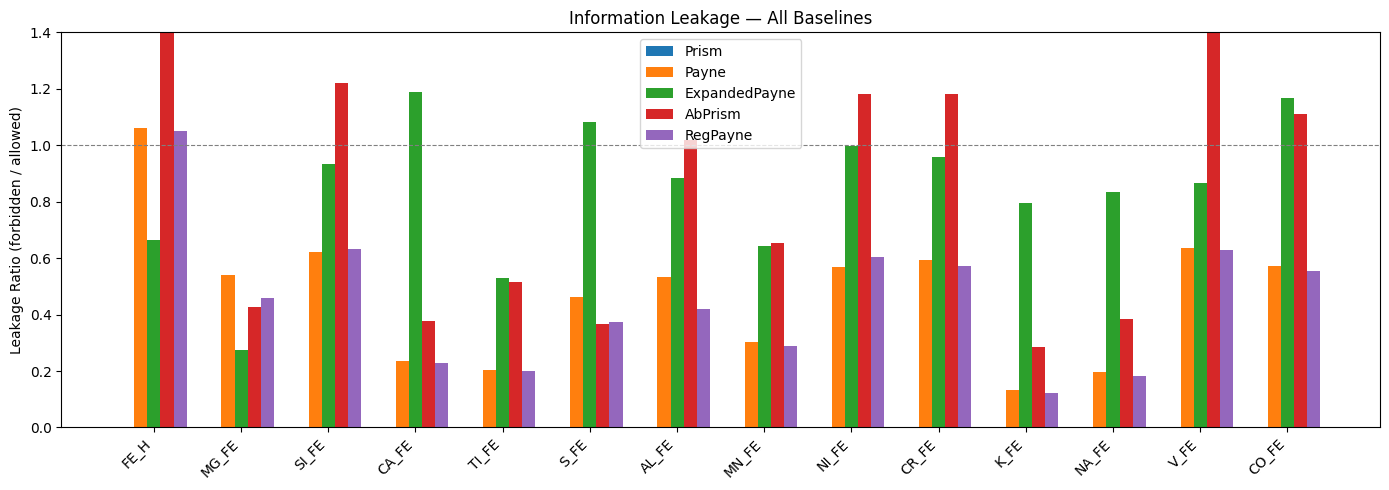

In [7]:
# ============================================================================
#  TEST 2: INFORMATION LEAKAGE (using apogee_mask.npy, full test set)
# ============================================================================
print("\n" + "=" * 60)
print("  TEST 2 — INFORMATION LEAKAGE")
print("=" * 60)

apogee_mask = np.load(apogee_mask_path)  # shape (8575, N_LABELS), convention: 0=allowed, >0=forbidden

LABELS_ORDER = config.SELECTED_LABELS + ['INV_TEFF', 'vbroad', 'C_O_diff', 'LOGPE']
ATOMIC_LABELS = [
    'FE_H', 'MG_FE', 'SI_FE', 'CA_FE', 'TI_FE', 'S_FE',
    'AL_FE', 'MN_FE', 'NI_FE', 'CR_FE', 'K_FE',
    'NA_FE', 'V_FE', 'CO_FE',
]


def compute_leakage(model_obj, model_name, test_lab, mask, bad_mask, epsilon=1e-4,isprism=False):
    """
    For each ATOMIC element, compute the gradient via finite difference,
    then measure how much response 'leaks' into pixels where the element
    has NO spectral line (forbidden region in apogee_mask).

    Stars with an imputed value for the label being tested are excluded.
    """
    print(f"\n  Leakage analysis for {model_name}:")

    # Use all test stars — batch through them
    batch_size = 512
    n_stars    = len(test_lab)
    n_batches  = n_stars // batch_size

    results = {}
    for label in ATOMIC_LABELS:
        if label not in LABELS_ORDER:
            continue
        col_idx = LABELS_ORDER.index(label)
        idx_in_selected = config.SELECTED_LABELS.index(label) if label in config.SELECTED_LABELS else None
        if idx_in_selected is None:
            continue

        # apogee_mask convention: 0 = line present (allowed), >0 = no line (forbidden)
        allowed = mask[:, col_idx] > 0
        forbidden = ~allowed

        total_grad_forbidden = 0.0
        total_grad_allowed   = 0.0
        count = 0

        for k in range(n_batches):
            s = k * batch_size
            e = (k + 1) * batch_size
            
            # Filter out stars in this batch where the label was imputed
            batch_bad_mask = bad_mask[s:e, idx_in_selected]
            batch_valid_mask = ~batch_bad_mask
            
            if not np.any(batch_valid_mask):
                continue
                
            batch = tf.cast(test_lab[s:e][batch_valid_mask], tf.float32)
            grad  = get_gradient(model_obj, batch, idx_in_selected, epsilon=epsilon,isprism=isprism)
            if len(grad.shape) > 2:
                grad = grad[:, :, 0]
            grad_abs = np.abs(grad.numpy())

            total_grad_forbidden += np.mean(grad_abs[:, forbidden])
            total_grad_allowed   += np.mean(grad_abs[:, allowed]) if np.any(allowed) else 0.0
            count += 1

        avg_forbidden = total_grad_forbidden / max(count, 1)
        avg_allowed   = total_grad_allowed   / max(count, 1)
        ratio = avg_forbidden / avg_allowed if avg_allowed > 0 else float('inf')
        results[label] = {'forbidden': avg_forbidden, 'allowed': avg_allowed, 'ratio': ratio}
        print(f"    {label:>8s}:  forbidden={avg_forbidden:.6f}  allowed={avg_allowed:.6f}  leak_ratio={ratio:.4f}")

    return results


# Run leakage for ALL baselines (using valid_stars only or all? User said "exclude stars that have an imputed label [X/H]")
# Usually we should use all stars but filtered by X imputation.
# However, the user said "run the other tests (test 1,2 ,3) on this new chi squared".
# This implies we should use the "valid_stars" (non-dropped) as the base population.
test_labels_v = test_labels[valid_stars]
test_bad_mask_v = test_bad_mask[valid_stars]

leakage_prism     = compute_leakage(model,         "Prism",         test_labels_v, apogee_mask, test_bad_mask_v,isprism=True)
leakage_payne     = compute_leakage(ThePayne,      "Payne",         test_labels_v, apogee_mask, test_bad_mask_v)
leakage_exp       = compute_leakage(ExpandedPayne, "ExpandedPayne", test_labels_v, apogee_mask, test_bad_mask_v)
leakage_AbPrism   = compute_leakage(base_AbPrism,  "AbPrism",       test_labels_v, apogee_mask, test_bad_mask_v)
leakage_rp        = compute_leakage(reg_Payne,     "RegPayne",      test_labels_v, apogee_mask, test_bad_mask_v)

# ── Leakage bar chart ──
all_leakage = {"Prism": leakage_prism, "Payne": leakage_payne,
               "ExpandedPayne": leakage_exp, "AbPrism": leakage_AbPrism, "RegPayne": leakage_rp}
elements = ATOMIC_LABELS
x_pos    = np.arange(len(elements))
width    = 0.15

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_ylim(0, 1.4)
for i, (name, leak) in enumerate(all_leakage.items()):
    ratios = [leak[el]['ratio'] if el in leak else 0 for el in elements]
    ax.bar(x_pos + i * width, ratios, width, label=name)
ax.set_xticks(x_pos + 2 * width)
ax.set_xticklabels(elements, rotation=45, ha='right')
ax.set_ylabel("Leakage Ratio (forbidden / allowed)")
ax.set_title("Information Leakage — All Baselines")
ax.legend()
ax.axhline(1.0, ls='--', color='grey', lw=0.8)
fig.tight_layout()
fig.savefig("leakage_comparison.png")
plt.show()


# In[8]:


Group                                         Model                 N   Median     Mean      P95      Std
----------------------------------------------------------------------------------------------------
RGB Tip (Teff<4000, logg<1.5)                 Prism               907    2.714    3.265    7.136    2.084
RGB Tip (Teff<4000, logg<1.5)                 Payne               907    2.593    3.101    6.678    1.888
RGB Tip (Teff<4000, logg<1.5)                 ExpandedPayne       907    2.982    3.632    7.754    2.548
RGB Tip (Teff<4000, logg<1.5)                 AbPrism             907    2.659    3.212    7.118    2.055
RGB Tip (Teff<4000, logg<1.5)                 RegPayne            907    2.610    3.116    6.739    1.916
RGB Giants (4000<Teff<5000, 1.5<logg<3.5)     Prism              6485    1.662    1.796    2.883    1.154
RGB Giants (4000<Teff<5000, 1.5<logg<3.5)     Payne              6485    1.627    1.750    2.804    1.266
RGB Giants (4000<Teff<5000, 1.5<logg<3.5)     Expa

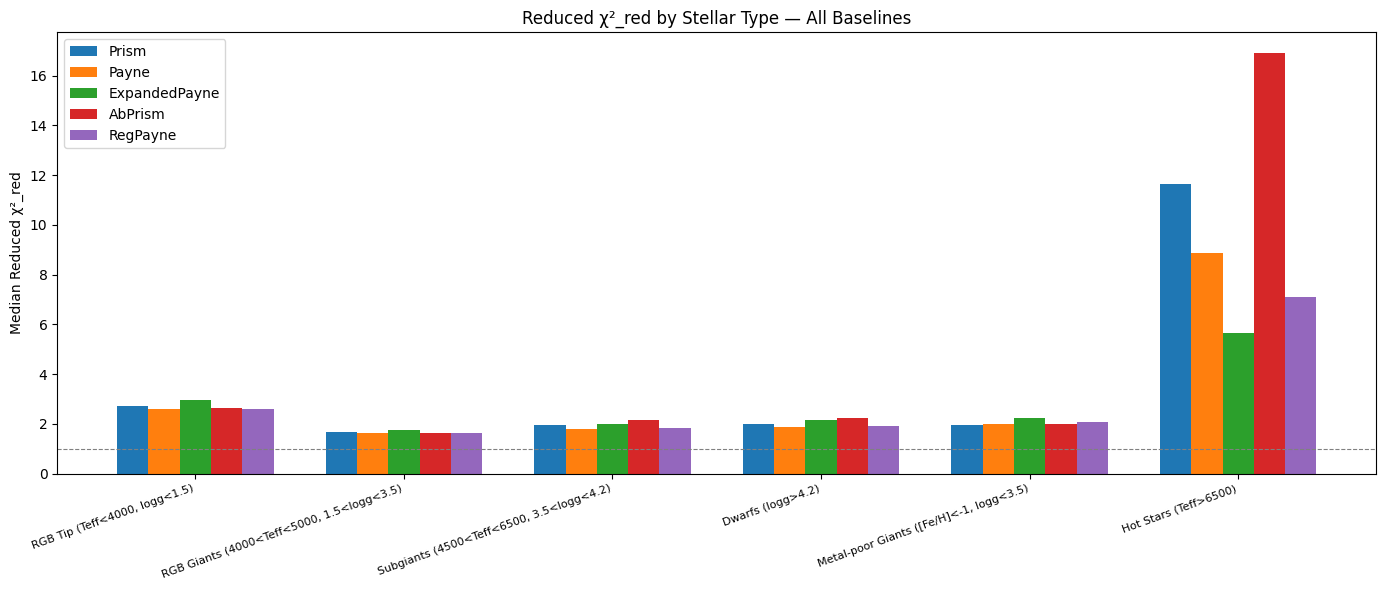

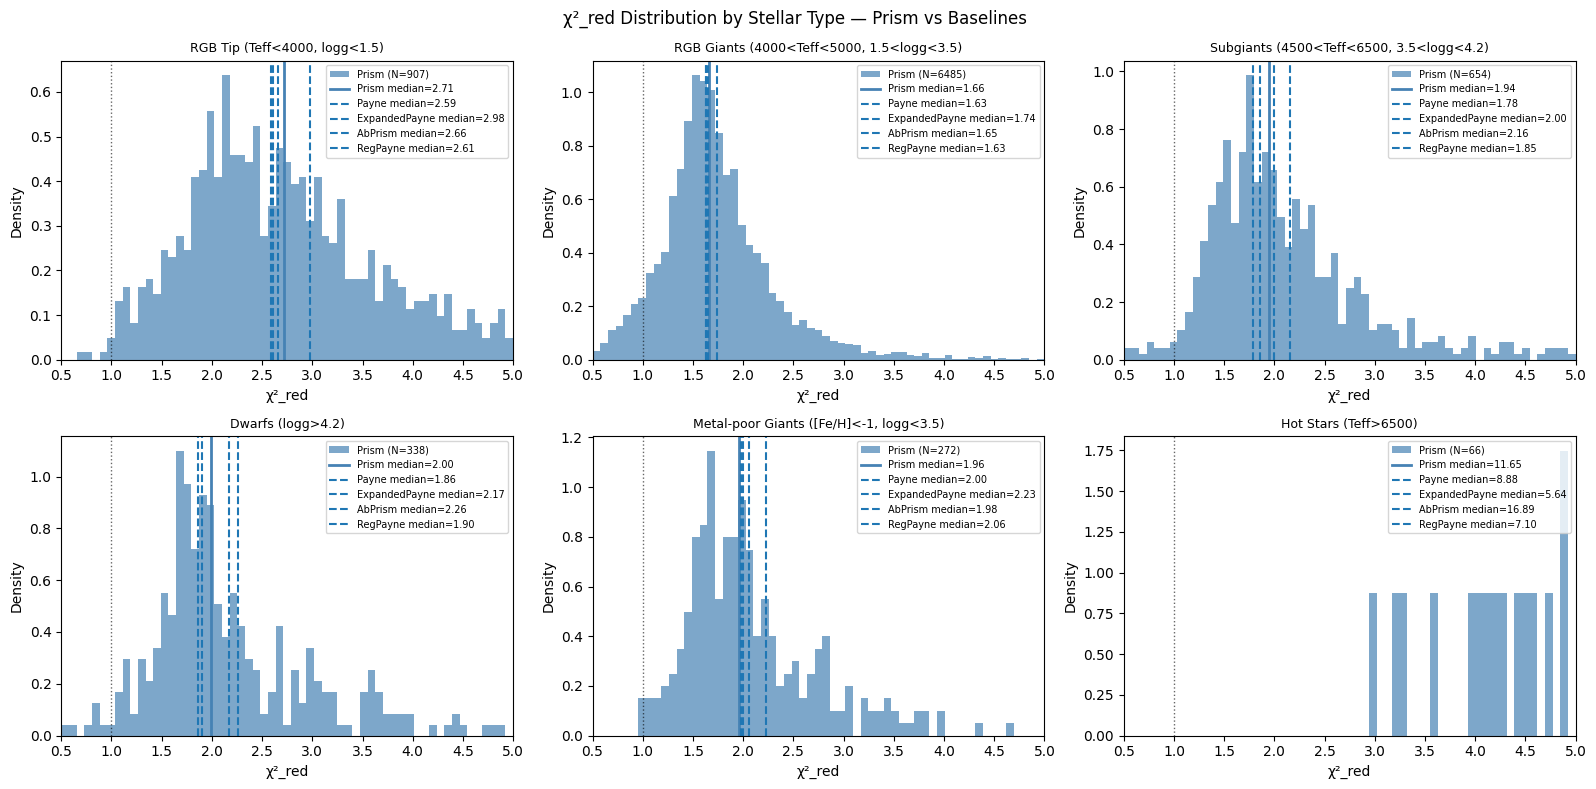


✓ All tests complete.


In [8]:
# ============================================================================
#  TEST 3: REDUCED CHI-SQUARED BY STELLAR TYPE
#
# De-normalise physical labels
teff_idx=config.SELECTED_LABELS.index("TEFF")
logg_idx=config.SELECTED_LABELS.index("LOGG")
feh_idx=config.SELECTED_LABELS.index("M_H")
teff_all = test_labels[:, teff_idx] * STD_TENSOR[teff_idx] + MEAN_TENSOR[teff_idx]
logg_all = test_labels[:, logg_idx] * STD_TENSOR[logg_idx] + MEAN_TENSOR[logg_idx]
feh_all  = test_labels[:, feh_idx]  * STD_TENSOR[feh_idx]  + MEAN_TENSOR[feh_idx]
model_chi2 = {
    "Prism":         test_chi2,
    "Payne":         test_chi2_P,
    "ExpandedPayne": test_chi2_EP,
    "AbPrism":           test_chi2_AbPrism,
    "RegPayne":      test_chi2_RP,
}
# ── Stellar type classification ──────────────────────────────────────────
# RGB tip / luminous giants: coolest, most evolved
mask_rgb_tip    = (teff_all < 4000) & (logg_all < 1.5)

# Standard RGB giants: APOGEE's dominant population
mask_rgb        = (teff_all >= 4000) & (teff_all < 5000) & \
                  (logg_all >= 1.5)  & (logg_all < 3.5)

# Subgiants: between main sequence and giant branch
mask_subgiant   = (teff_all >= 4500) & (teff_all < 6500) & \
                  (logg_all >= 3.5)  & (logg_all < 4.2)

# Main sequence / dwarfs: high logg
mask_dwarf      = (logg_all >= 4.2)

# Metal-poor giants: separate because line strengths are categorically different
mask_metal_poor = (feh_all < -1.0) & (logg_all < 3.5)

# Hot stars: OOD for this model
mask_hot        = teff_all > 6500

stellar_groups = {
    "RGB Tip (Teff<4000, logg<1.5)":           mask_rgb_tip,
    "RGB Giants (4000<Teff<5000, 1.5<logg<3.5)": mask_rgb,
    "Subgiants (4500<Teff<6500, 3.5<logg<4.2)":  mask_subgiant,
    "Dwarfs (logg>4.2)":                          mask_dwarf,
    "Metal-poor Giants ([Fe/H]<-1, logg<3.5)":   mask_metal_poor,
    "Hot Stars (Teff>6500)":                      mask_hot,
}

fig_bar, ax_bar = plt.subplots(figsize=(14, 6))
fig_dist, axes_dist = plt.subplots(
    2, 3, figsize=(16, 8), sharey=False
)
axes_dist = axes_dist.flatten()

x         = np.arange(len(stellar_groups))
bar_width = 0.15
summary_rows = []

for gi, (group_name, gmask) in enumerate(stellar_groups.items()):
    ax = axes_dist[gi]
    
    for mi, (model_name, chi2) in enumerate(model_chi2.items()):
        n    = min(len(chi2), len(gmask))
        gm   = gmask[:n]
        vals = chi2[:n][gm]
        if len(vals) == 0:
            continue

        summary_rows.append({
            'Group':   group_name,
            'Model':   model_name,
            'N_stars': int(np.sum(gm)),
            'Median':  float(np.median(vals)),
            'Mean':    float(np.mean(vals)),
            'P95':     float(np.percentile(vals, 95)),
            'Std':     float(np.std(vals)),
        })

        # Distribution plot — Prism only, with per-model median lines
        if model_name == "Prism":
            ax.hist(
                vals,
                bins=np.linspace(0.5, 5.0, 60),
                density=True,
                alpha=0.7,
                color='steelblue',
                edgecolor='none',
                label=f"Prism (N={len(vals)})"
            )
            ax.axvline(
                np.median(vals),
                color='steelblue',
                lw=2,
                ls='-',
                label=f"Prism median={np.median(vals):.2f}"
            )
        else:
            # Overlay median lines for baselines only (no histogram)
            median_val = np.median(vals)
            ax.axvline(
                median_val,
                lw=1.5,
                ls='--',
                label=f"{model_name} median={median_val:.2f}"
            )

    ax.axvline(1.0, color='black', lw=1.0, ls=':', alpha=0.6)
    ax.set_title(group_name, fontsize=9)
    ax.set_xlabel("χ²_red")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(0.5, 5.0)

fig_dist.suptitle("χ²_red Distribution by Stellar Type — Prism vs Baselines", fontsize=12)
fig_dist.tight_layout()
fig_dist.savefig("chi2_distribution_by_type.png", dpi=150)

# ── Bar chart (median χ²_red, all models) ───────────────────────────────
group_names = list(stellar_groups.keys())
model_names = list(model_chi2.keys())

for mi, mname in enumerate(model_names):
    medians = []
    for gname in group_names:
        match = [r for r in summary_rows
                 if r['Group'] == gname and r['Model'] == mname]
        medians.append(match[0]['Median'] if match else 0)
    ax_bar.bar(x + mi * bar_width, medians, bar_width, label=mname)

ax_bar.set_xticks(x + (len(model_names) - 1) * bar_width / 2)
ax_bar.set_xticklabels(group_names, rotation=20, ha='right', fontsize=8)
ax_bar.set_ylabel("Median Reduced χ²_red")
ax_bar.set_title("Reduced χ²_red by Stellar Type — All Baselines")
ax_bar.axhline(1.0, ls='--', color='grey', lw=0.8)
ax_bar.legend()
fig_bar.tight_layout()
fig_bar.savefig("chi2_by_stellar_type.png", dpi=150)

# ── Summary table ────────────────────────────────────────────────────────
print(f"\n{'Group':<45s} {'Model':<16s} {'N':>6s} "
      f"{'Median':>8s} {'Mean':>8s} {'P95':>8s} {'Std':>8s}")
print("-" * 100)
for r in summary_rows:
    print(f"{r['Group']:<45s} {r['Model']:<16s} {r['N_stars']:>6d} "
          f"{r['Median']:>8.3f} {r['Mean']:>8.3f} {r['P95']:>8.3f} {r['Std']:>8.3f}")

plt.show()
print("\n✓ All tests complete.")


# In[ ]: